# Fault signature exploration — 15 Jan 2026

This notebook loads:
- **Telemetry CSV** containing ~1 month of data for one vehicle
- **Fault CSV** containing fault events for **15/01/2026**

It then:
1. Parses timestamps (day-first)
2. Filters telemetry to **15 Jan 2026**
3. Overlays fault intervals on time-series plots
4. Generates per-fault zoomed-in plots (pre/post windows)
5. Computes simple before-vs-baseline deltas to spot correlations


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Set file paths here
# -------------------------
# Upload your files into the same folder as this notebook (or update these paths).
TELEMETRY_CSV = Path("/Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-02-24/vehicle_id=EV01.csv")       # month telemetry export
FAULTS_CSV    = Path("/Users/rhythmparashar/Desktop/ev-predictive-analytics/faults_2026-01-15.csv")    # faults for 15 Jan only

# Vehicle identifier (optional; used in titles)
VEHICLE_ID = "EV01"

# Date to analyze
DAY = "2026-01-15"  # YYYY-MM-DD

# Plot windows
PRE_MIN  = 20   # minutes before fault activation
POST_MIN = 10   # minutes after fault fixed

print("Telemetry CSV:", TELEMETRY_CSV.resolve())
print("Faults CSV:", FAULTS_CSV.resolve())


Telemetry CSV: /Users/rhythmparashar/Desktop/ev-predictive-analytics/data/raw/dt=2026-02-24/vehicle_id=EV01.csv
Faults CSV: /Users/rhythmparashar/Desktop/ev-predictive-analytics/faults_2026-01-15.csv


In [2]:
# -------------------------
# Load telemetry
# -------------------------
tel = pd.read_csv(TELEMETRY_CSV)

# Parse telemetry timestamp (day-first)
if "Timestamp" not in tel.columns:
    raise ValueError("Telemetry CSV must have a 'Timestamp' column. Update parsing if your header differs.")

tel["Timestamp"] = pd.to_datetime(tel["Timestamp"], errors="coerce", dayfirst=True)
bad_ts = int(tel["Timestamp"].isna().sum())
print("Telemetry rows:", len(tel), "| bad timestamps:", bad_ts)

# Normalize column names we will use (only if present)
COL_MAP = {
    "Stack Voltage (V)": "stack_voltage_v",
    "Battery Current (A)": "battery_current_a",
    "Output Power (kW)": "output_power_kw",
    "Motor Speed (RPM)": "motor_speed_rpm",
    "SOC (%)": "soc_pct",
    "DC Side Voltage (V)": "dc_side_voltage_v",
    "Avg Battery Temp (°C)": "avg_battery_temp_c",
    "Max Battery Temp (°C)": "max_battery_temp_c",
    "Min Battery Temp (°C)": "min_battery_temp_c",
    "MCU Enable State": "mcu_enable_state",
}

for k, v in COL_MAP.items():
    if k in tel.columns:
        tel.rename(columns={k: v}, inplace=True)

# Coerce key numeric columns to numeric
NUM_COLS = [
    "stack_voltage_v","battery_current_a","output_power_kw","motor_speed_rpm","soc_pct",
    "dc_side_voltage_v","avg_battery_temp_c","max_battery_temp_c","min_battery_temp_c",
]
for c in NUM_COLS:
    if c in tel.columns:
        tel[c] = pd.to_numeric(tel[c], errors="coerce")

# Optional: normalize MCU Enable State if present
if "mcu_enable_state" in tel.columns:
    tel["mcu_enable_state"] = (
        tel["mcu_enable_state"].astype(str).str.strip().str.lower()
        .map({"enabled": 1, "disabled": 0, "1": 1, "0": 0})
    )

tel = tel.sort_values("Timestamp").reset_index(drop=True)

# Filter to the day of interest
day_start = pd.Timestamp(DAY)
day_end = day_start + pd.Timedelta(days=1)
tel_day = tel[(tel["Timestamp"] >= day_start) & (tel["Timestamp"] < day_end)].copy()
print("Telemetry rows on", DAY, ":", len(tel_day))

tel_day.head()

Telemetry rows: 646422 | bad timestamps: 0
Telemetry rows on 2026-01-15 : 11339


,Timestamp,soc_pct,Battery Status,stack_voltage_v,battery_current_a,output_power_kw,Charger Current Demand (A),Charger Voltage Demand (V),Max Cell Voltage (V),Min Cell Voltage (V),...,DCDC Pri C MOSFET Temp (°C),DCDC Input Voltage (V),DCDC Input Current (A),DCDC Output Voltage (V),DCDC Output Current (A),DCDC Overcurrent Count,Total Running Hours,Last Trip Hours,Total kWh Consumed,Last Trip kWh
0,2026-01-15 11:15:05,91.0,Discharging,587.626,42.0,24.680,0.0,0.0,3.301,3.281,...,45.0,590.0,1.4,27.9,29.0,0.0,62:26:06,00:10:52,1638.836,3.15
1,2026-01-15 11:15:05,91.0,Discharging,589.301,42.0,24.751,0.0,0.0,3.301,3.281,...,45.0,590.0,1.4,27.9,29.0,0.0,62:26:06,00:10:52,1638.836,3.15
2,2026-01-15 11:15:06,91.0,Discharging,589.290,42.0,24.750,0.0,0.0,3.301,3.281,...,45.0,590.0,1.4,27.9,29.0,0.0,62:26:13,00:10:59,1638.836,3.15
3,2026-01-15 11:15:07,91.0,Discharging,587.549,42.0,24.677,0.0,0.0,3.301,3.281,...,45.0,591.0,1.4,28.0,29.0,0.0,62:26:13,00:10:59,1638.836,3.15
4,2026-01-15 11:15:07,91.0,Discharging,587.549,42.0,24.677,0.0,0.0,3.301,3.281,...,45.0,591.0,1.4,28.0,29.0,0.0,62:26:13,00:10:59,1638.836,3.15


In [3]:
# -------------------------
# Load faults
# -------------------------
faults = pd.read_csv(FAULTS_CSV)

# Accept either 'Activated At'/'Fixed At' or already normalized headers
if "Activated At" in faults.columns:
    faults.rename(columns={"Activated At": "activated_at", "Fixed At": "fixed_at", "Code": "code", "Description": "description"}, inplace=True)

required = {"activated_at", "fixed_at", "code"}
missing = required - set(faults.columns)
if missing:
    raise ValueError(f"Fault CSV missing columns: {missing}. Expected Activated At/Fixed At/Code (or activated_at/fixed_at/code)")

faults["activated_at"] = pd.to_datetime(faults["activated_at"], errors="coerce", dayfirst=True)
faults["fixed_at"] = pd.to_datetime(faults["fixed_at"], errors="coerce", dayfirst=True)

faults = faults.dropna(subset=["activated_at", "fixed_at", "code"]).sort_values("activated_at").reset_index(drop=True)
print("Fault events:", len(faults))
faults

Fault events: 8


,activated_at,fixed_at,code,description
0,2026-01-15 17:12:56,2026-01-15 17:13:57,busbar_undervoltage_fault,Busbar Undervoltage Fault
1,2026-01-15 17:14:13,2026-01-15 17:14:57,busbar_undervoltage_fault,Busbar Undervoltage Fault
2,2026-01-15 17:19:38,2026-01-15 17:19:58,bus_overvoltage_fault,Bus Overvoltage Fault
3,2026-01-15 17:19:38,2026-01-15 17:19:58,total_hardware_failure,Total Hardware Failure
4,2026-01-15 17:19:38,2026-01-15 17:19:58,hardware_overvoltage_fault,Hardware Overvoltage Fault
5,2026-01-15 17:19:38,2026-01-15 17:19:58,busbar_undervoltage_fault,Busbar Undervoltage Fault
6,2026-01-15 17:37:30,2026-01-15 18:27:49,busbar_undervoltage_fault,Busbar Undervoltage Fault
7,2026-01-15 18:38:41,2026-01-15 18:38:58,busbar_undervoltage_fault,Busbar Undervoltage Fault


Signals plotted: ['stack_voltage_v', 'battery_current_a', 'output_power_kw', 'motor_speed_rpm', 'avg_battery_temp_c']


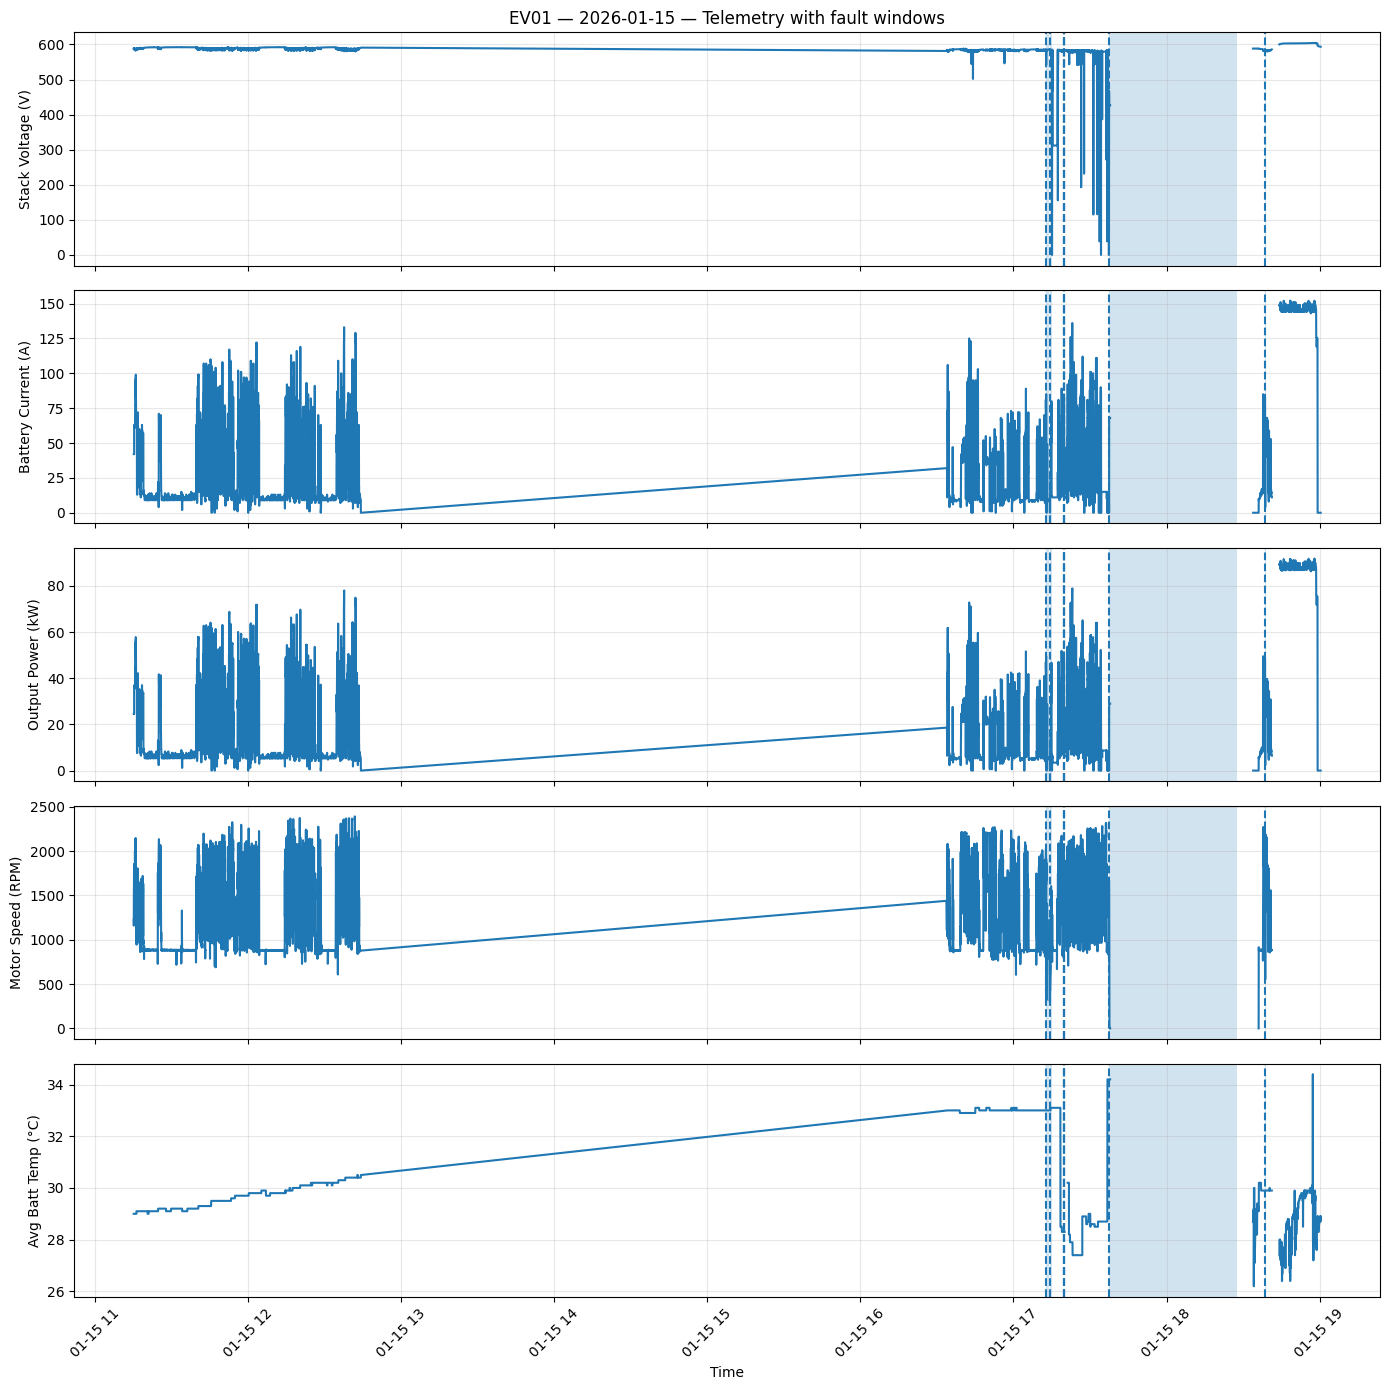

In [4]:
# -------------------------
# Plot full-day overview with fault intervals overlaid
# -------------------------
if len(tel_day) == 0:
    raise RuntimeError("No telemetry rows for the selected day. Check DAY or CSV timestamps.")

signals = [
    ("stack_voltage_v", "Stack Voltage (V)"),
    ("battery_current_a", "Battery Current (A)"),
    ("output_power_kw", "Output Power (kW)"),
    ("motor_speed_rpm", "Motor Speed (RPM)"),
    ("avg_battery_temp_c", "Avg Batt Temp (°C)"),
]

signals = [(c, lbl) for c, lbl in signals if c in tel_day.columns]
print("Signals plotted:", [c for c,_ in signals])

fig, axes = plt.subplots(len(signals), 1, figsize=(14, 2.8*len(signals)), sharex=True)
if len(signals) == 1:
    axes = [axes]

for ax, (c, lbl) in zip(axes, signals):
    ax.plot(tel_day["Timestamp"], tel_day[c])
    ax.set_ylabel(lbl)
    ax.grid(True, alpha=0.3)

    for _, r in faults.iterrows():
        ax.axvspan(r["activated_at"], r["fixed_at"], alpha=0.2)
        ax.axvline(r["activated_at"], linestyle="--")

axes[0].set_title(f"{VEHICLE_ID} — {DAY} — Telemetry with fault windows")
axes[-1].set_xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


[1/8] busbar_undervoltage_fault | 2026-01-15 17:12:56 -> 2026-01-15 17:13:57


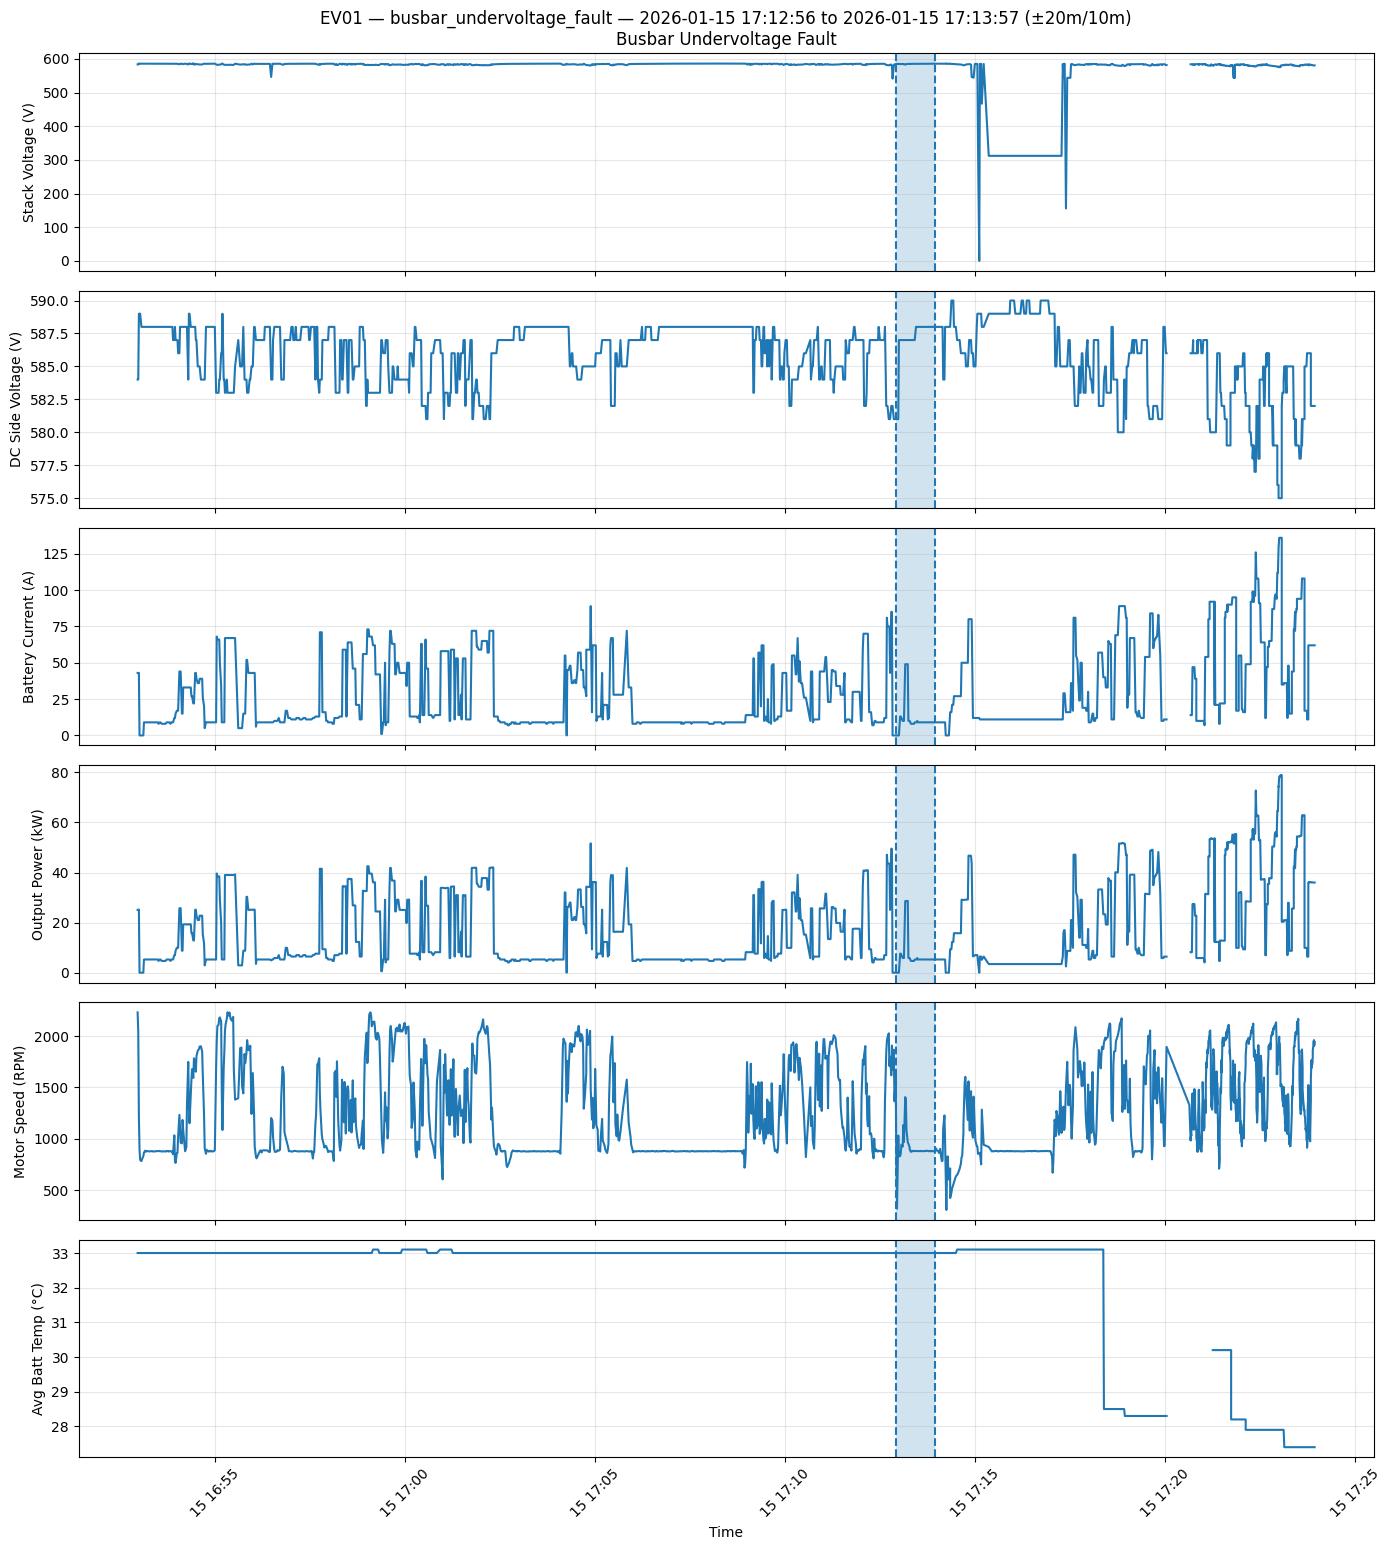


[2/8] busbar_undervoltage_fault | 2026-01-15 17:14:13 -> 2026-01-15 17:14:57


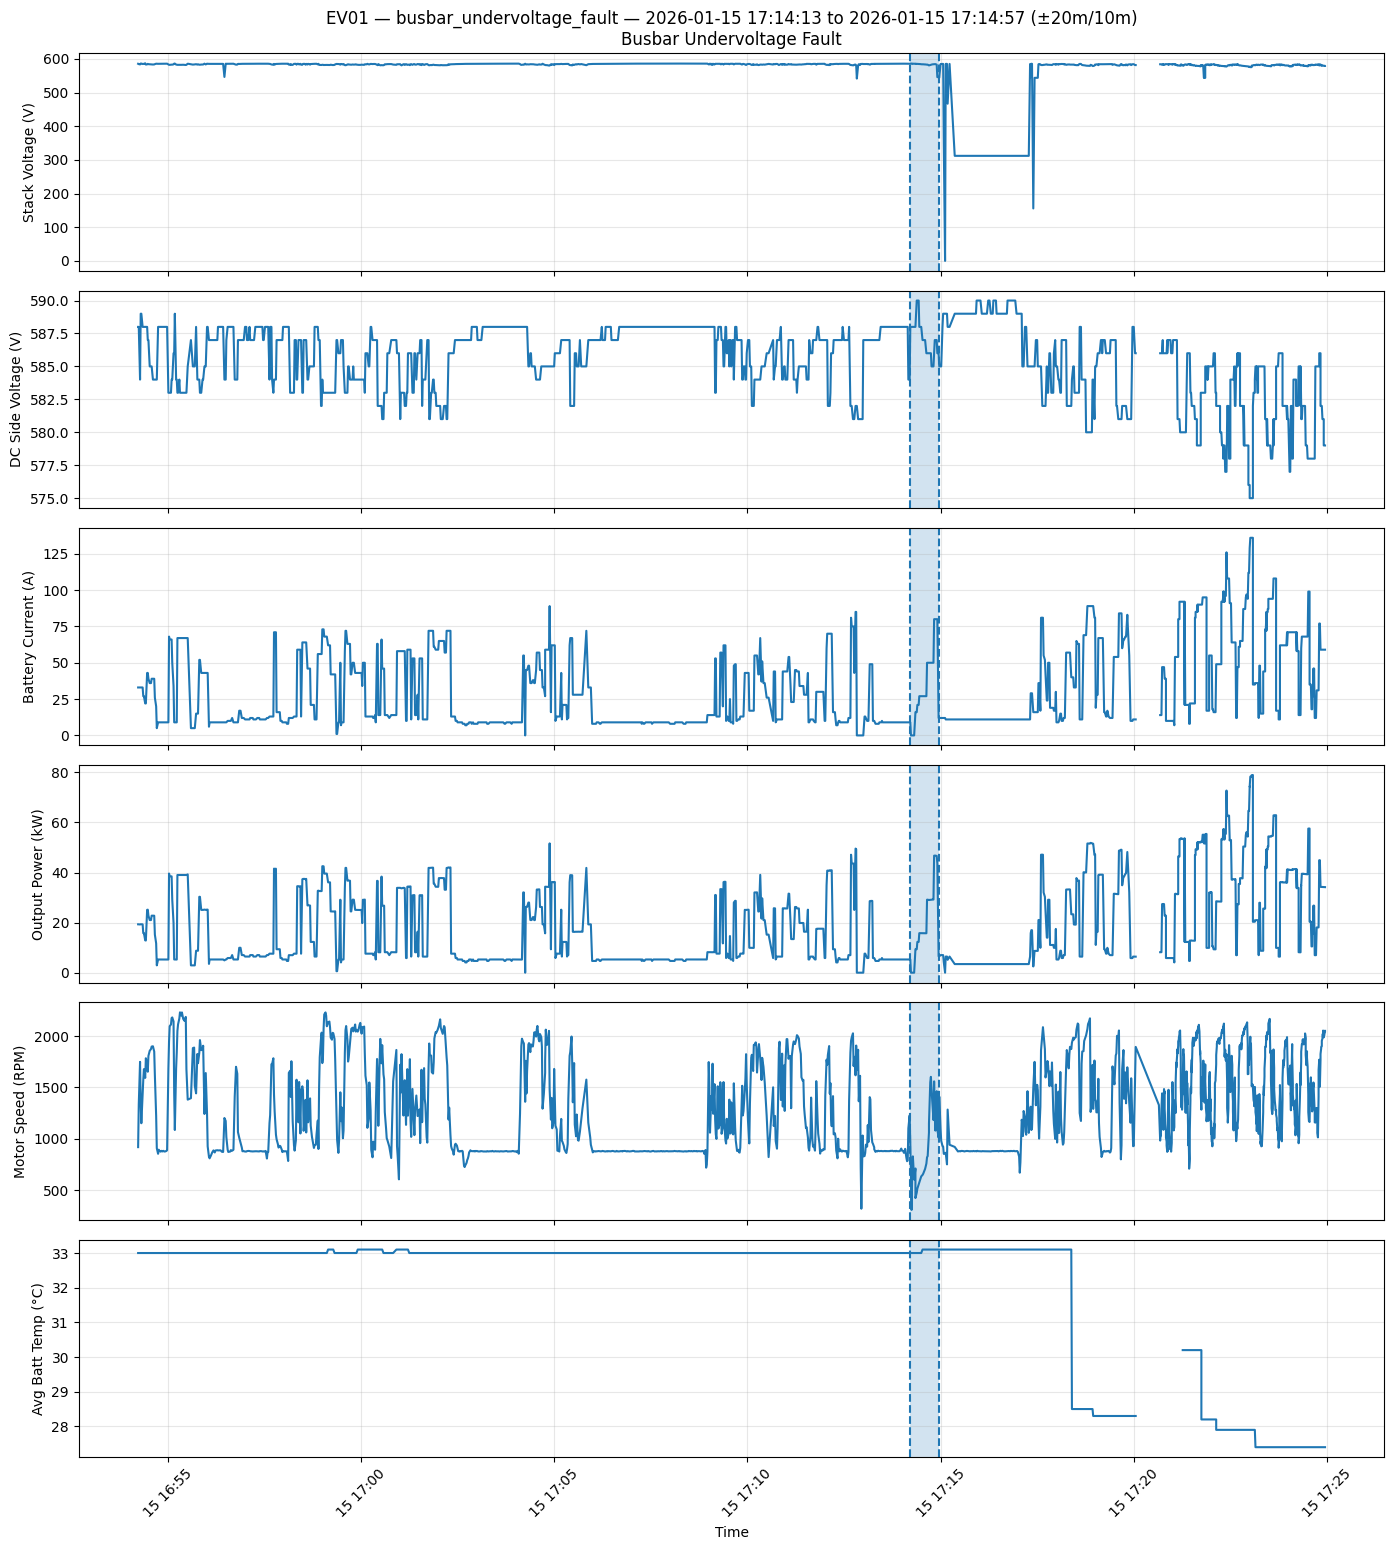


[3/8] bus_overvoltage_fault | 2026-01-15 17:19:38 -> 2026-01-15 17:19:58


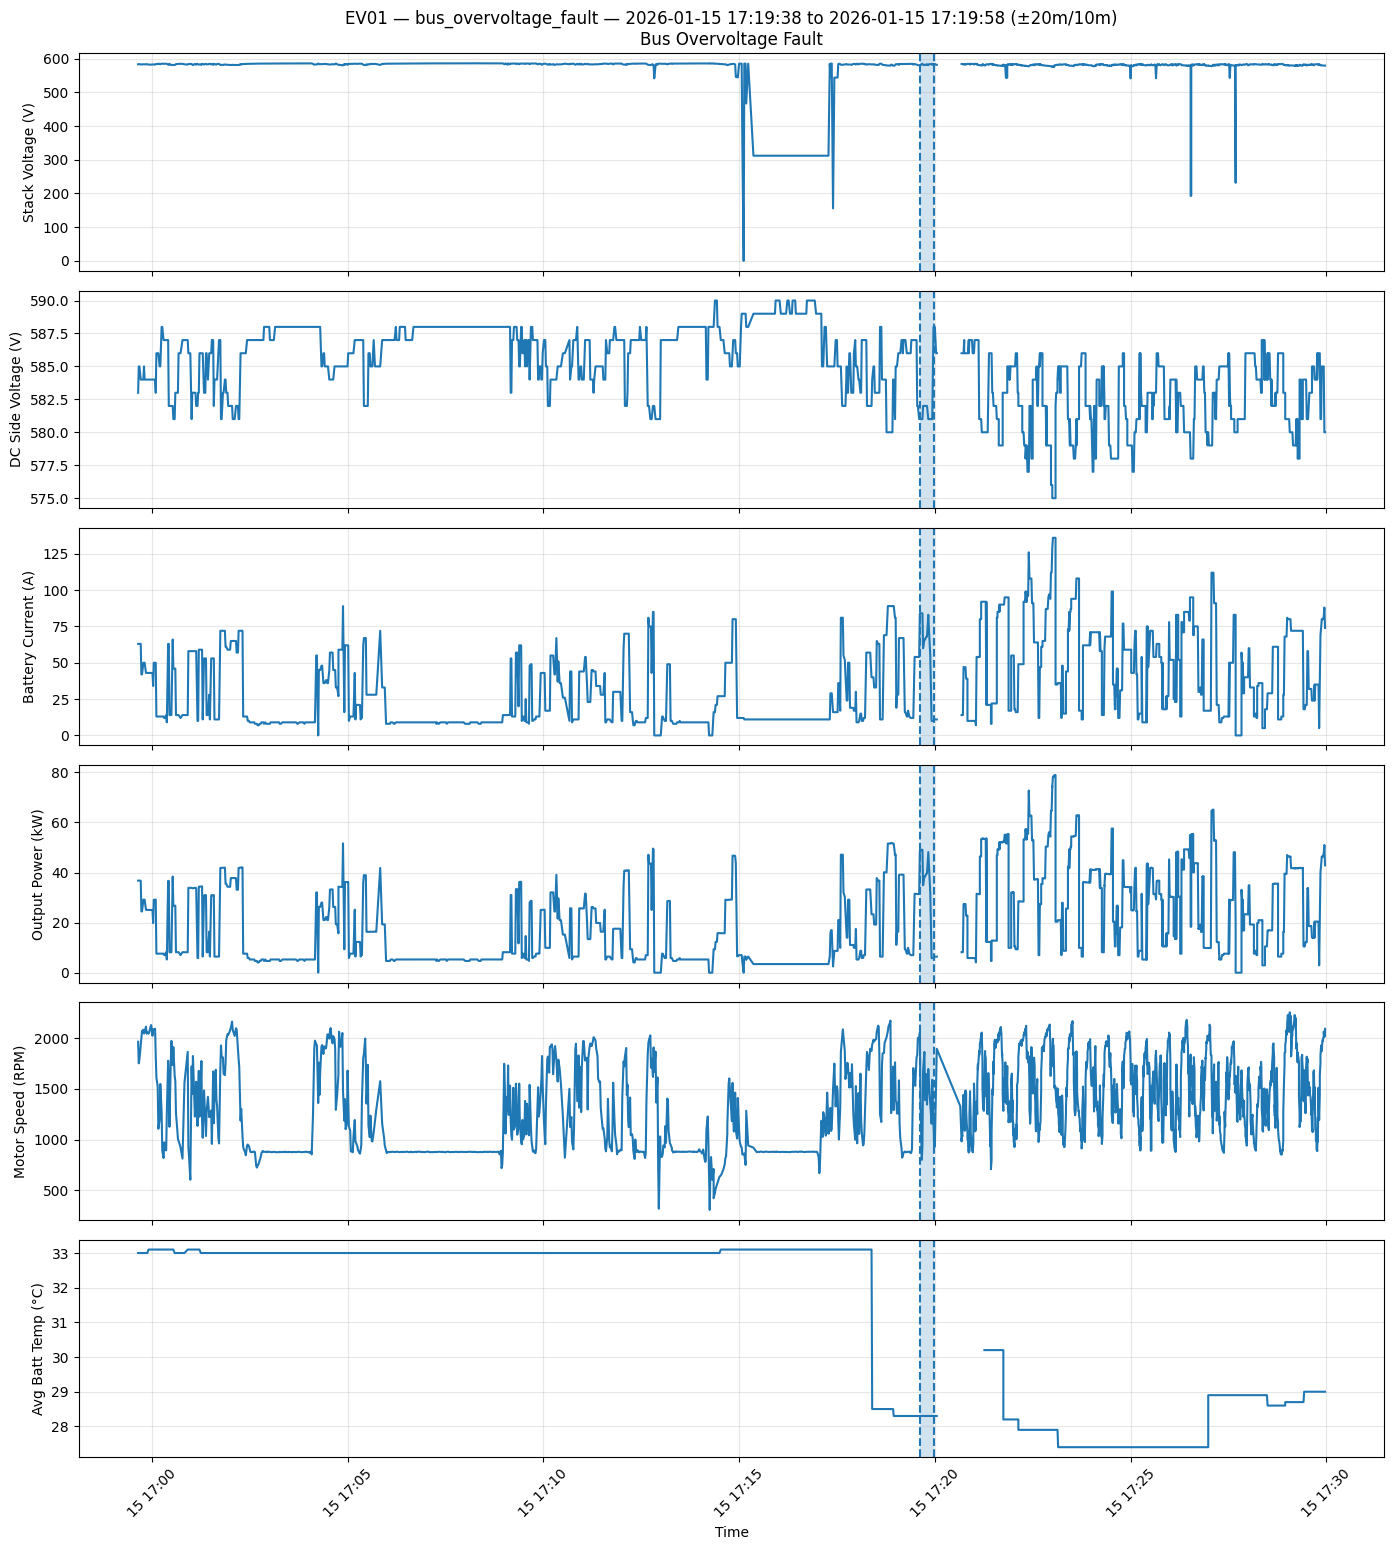


[4/8] total_hardware_failure | 2026-01-15 17:19:38 -> 2026-01-15 17:19:58


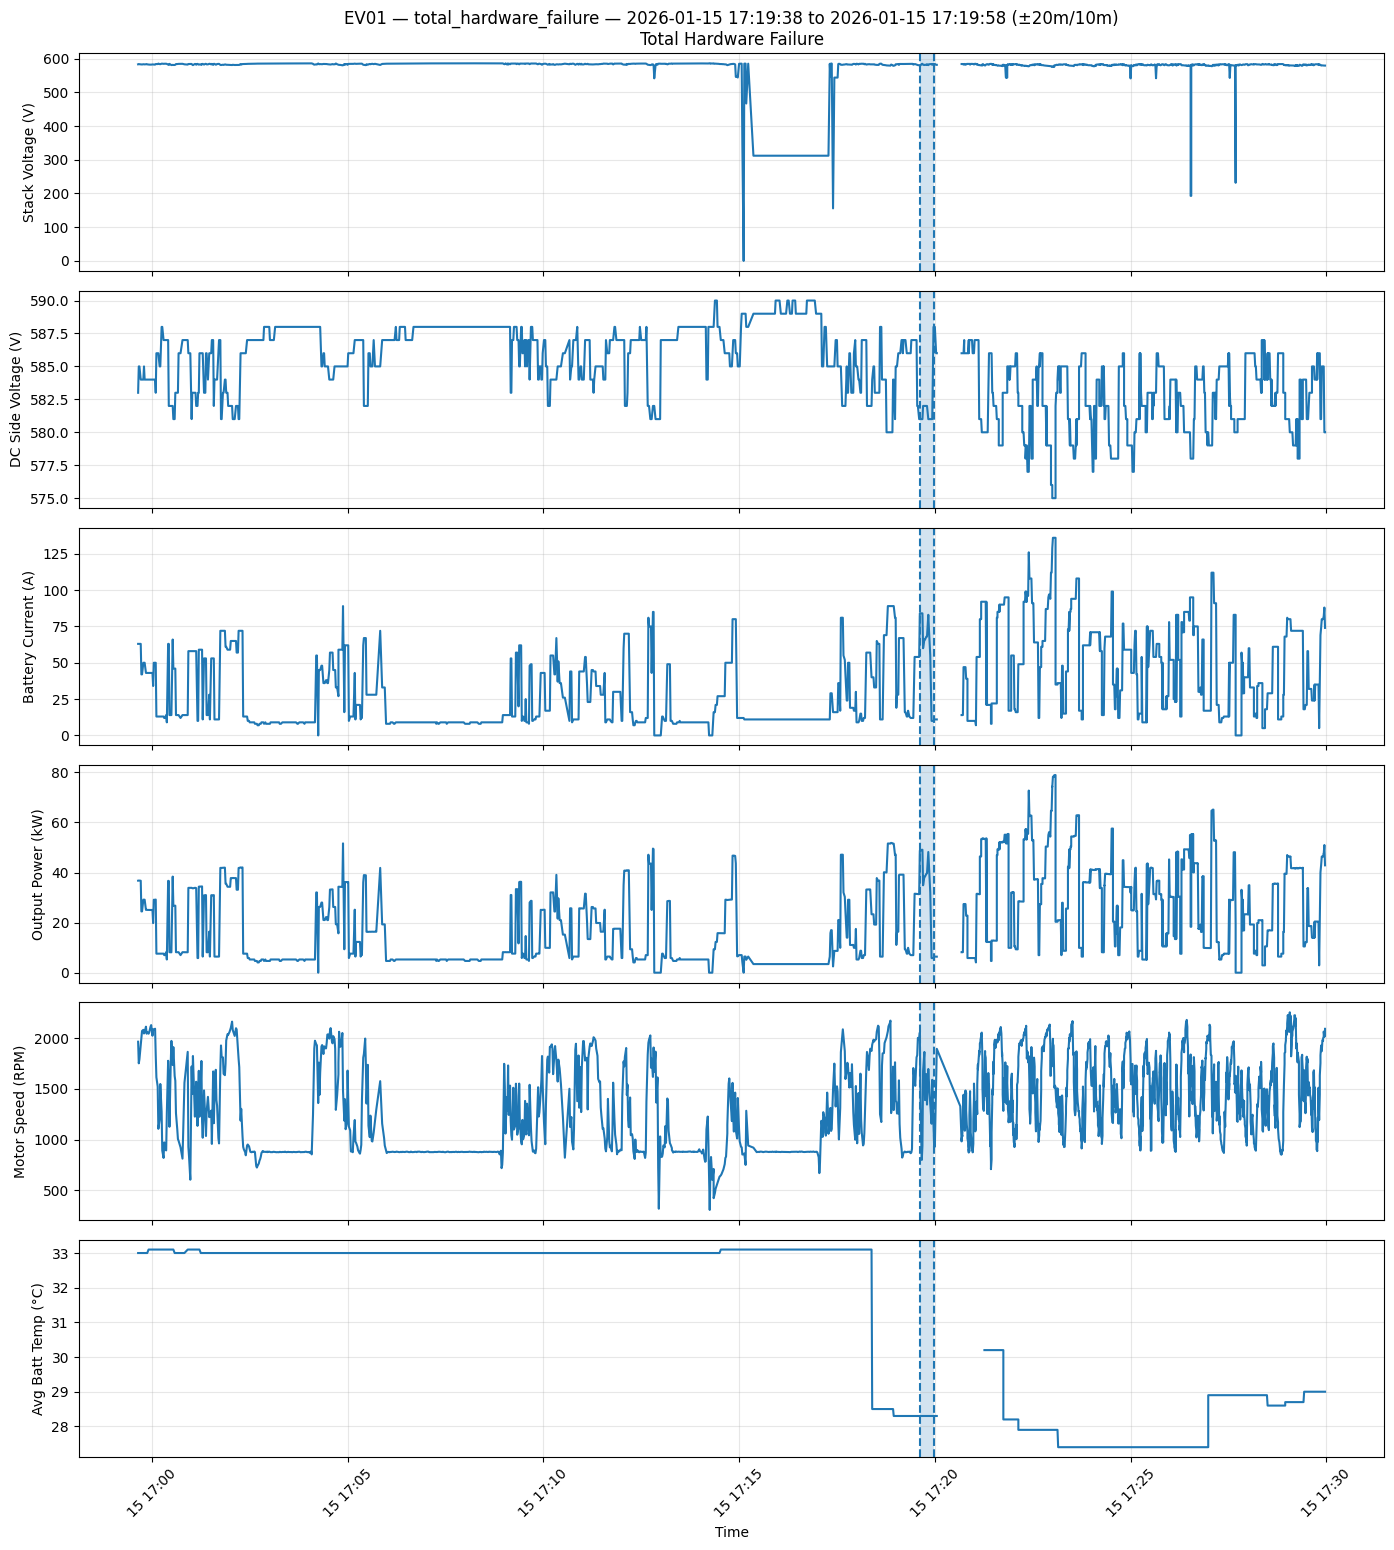


[5/8] hardware_overvoltage_fault | 2026-01-15 17:19:38 -> 2026-01-15 17:19:58


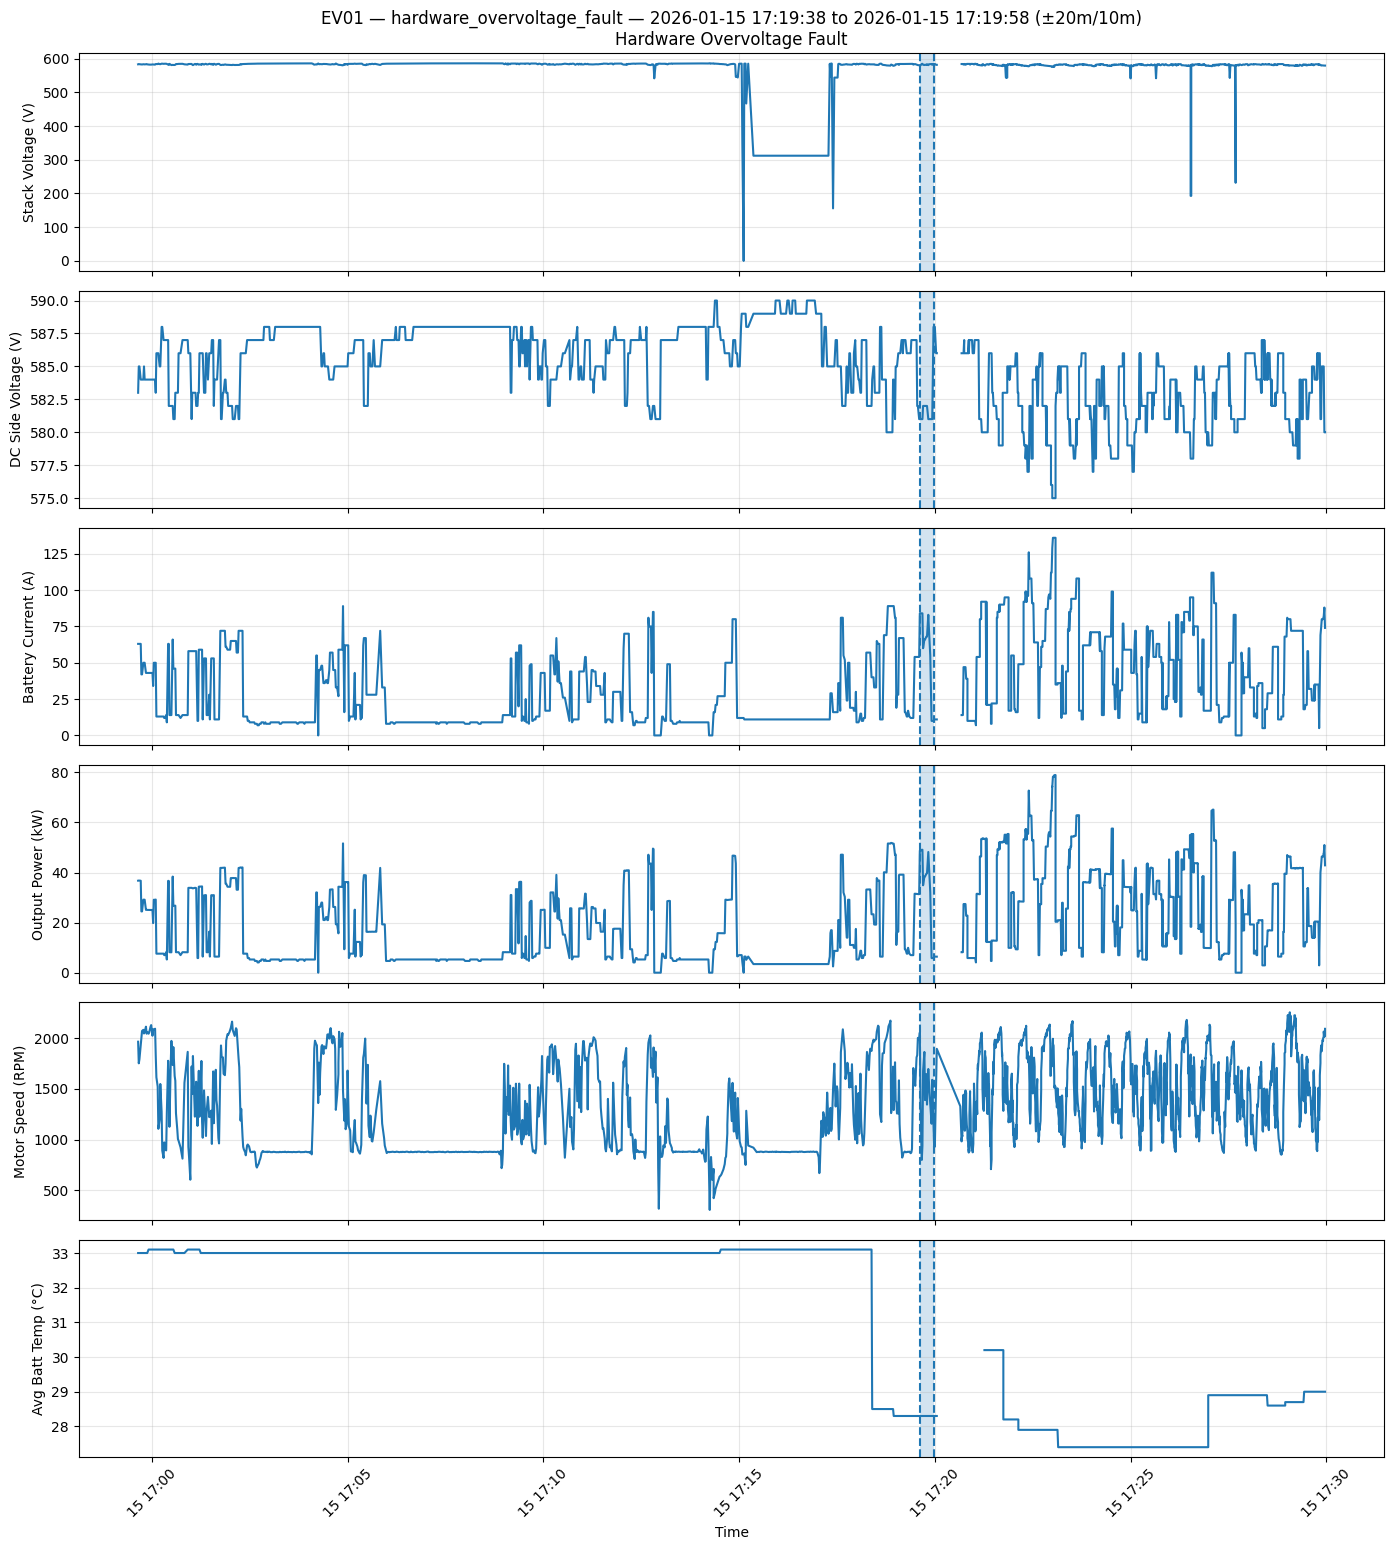


[6/8] busbar_undervoltage_fault | 2026-01-15 17:19:38 -> 2026-01-15 17:19:58


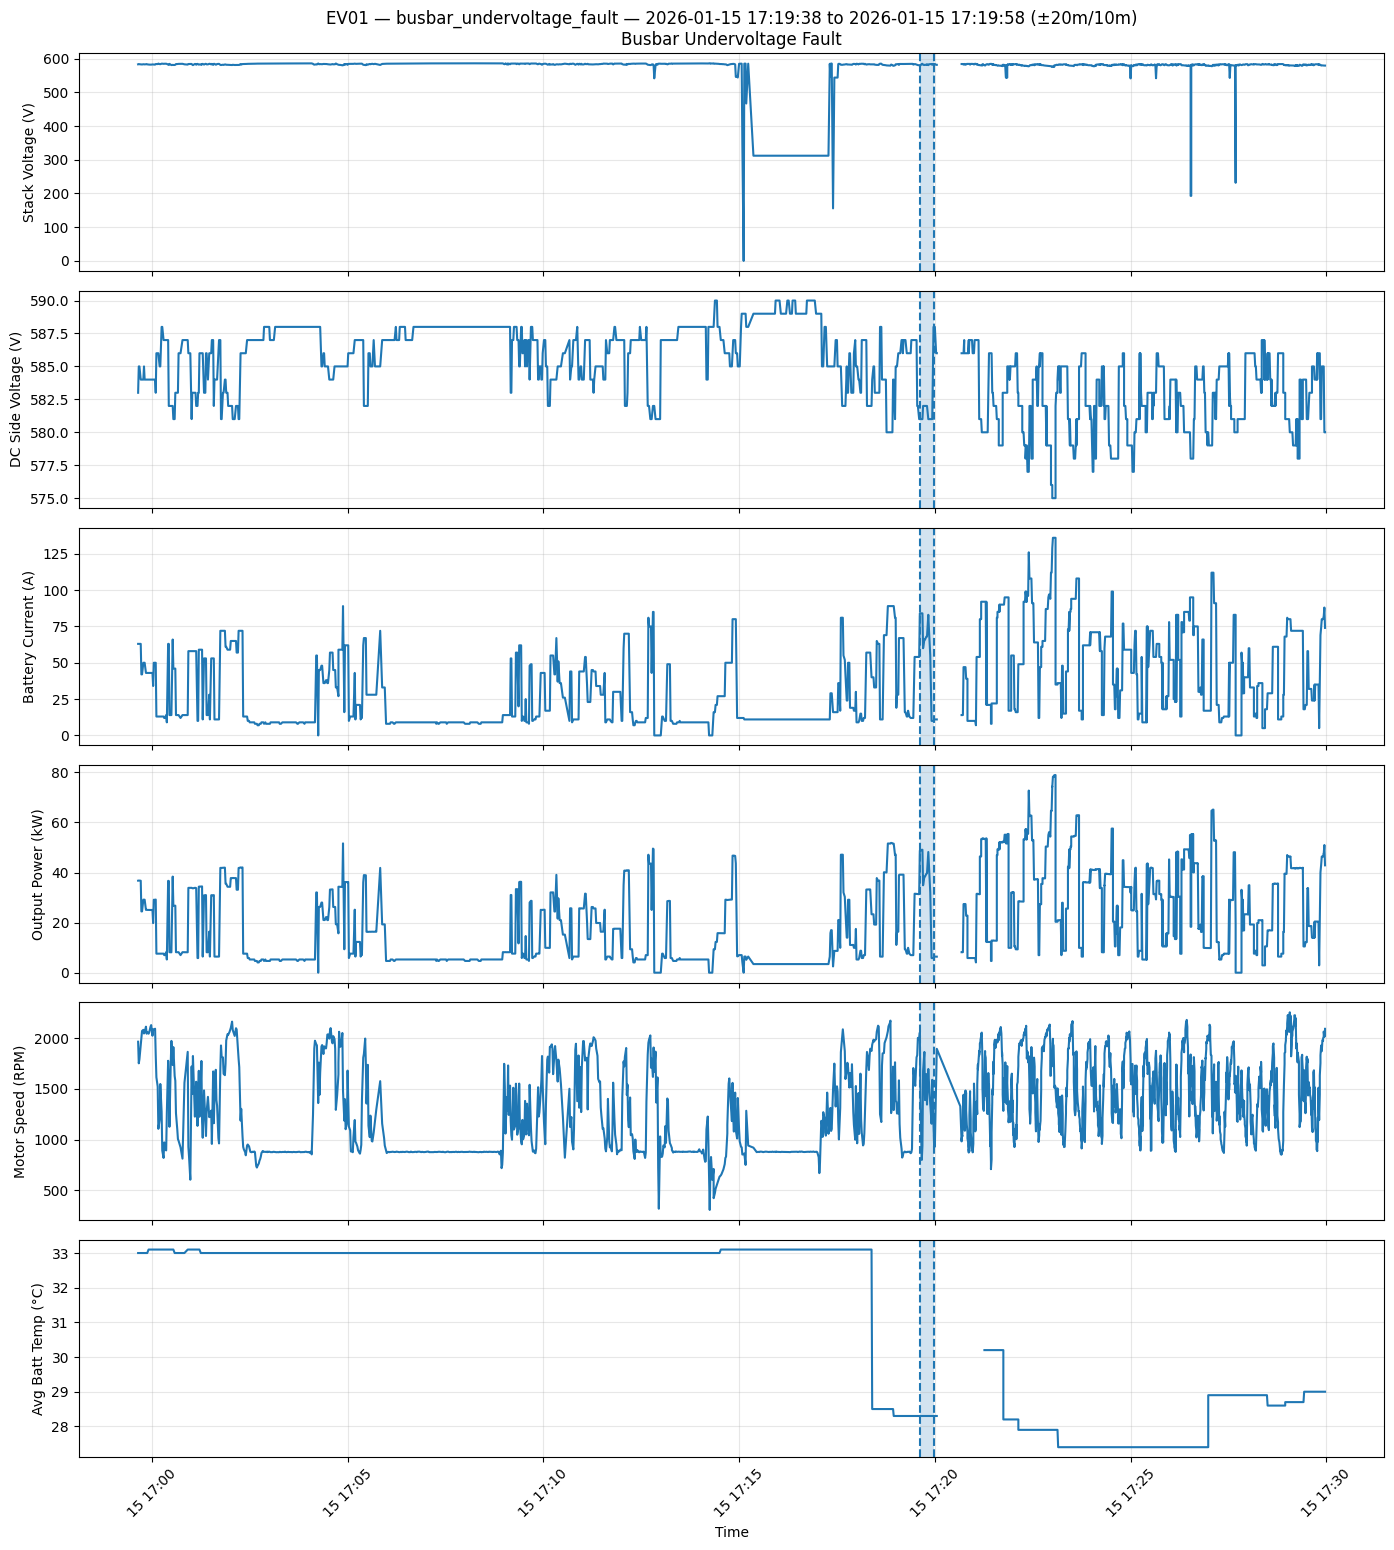


[7/8] busbar_undervoltage_fault | 2026-01-15 17:37:30 -> 2026-01-15 18:27:49


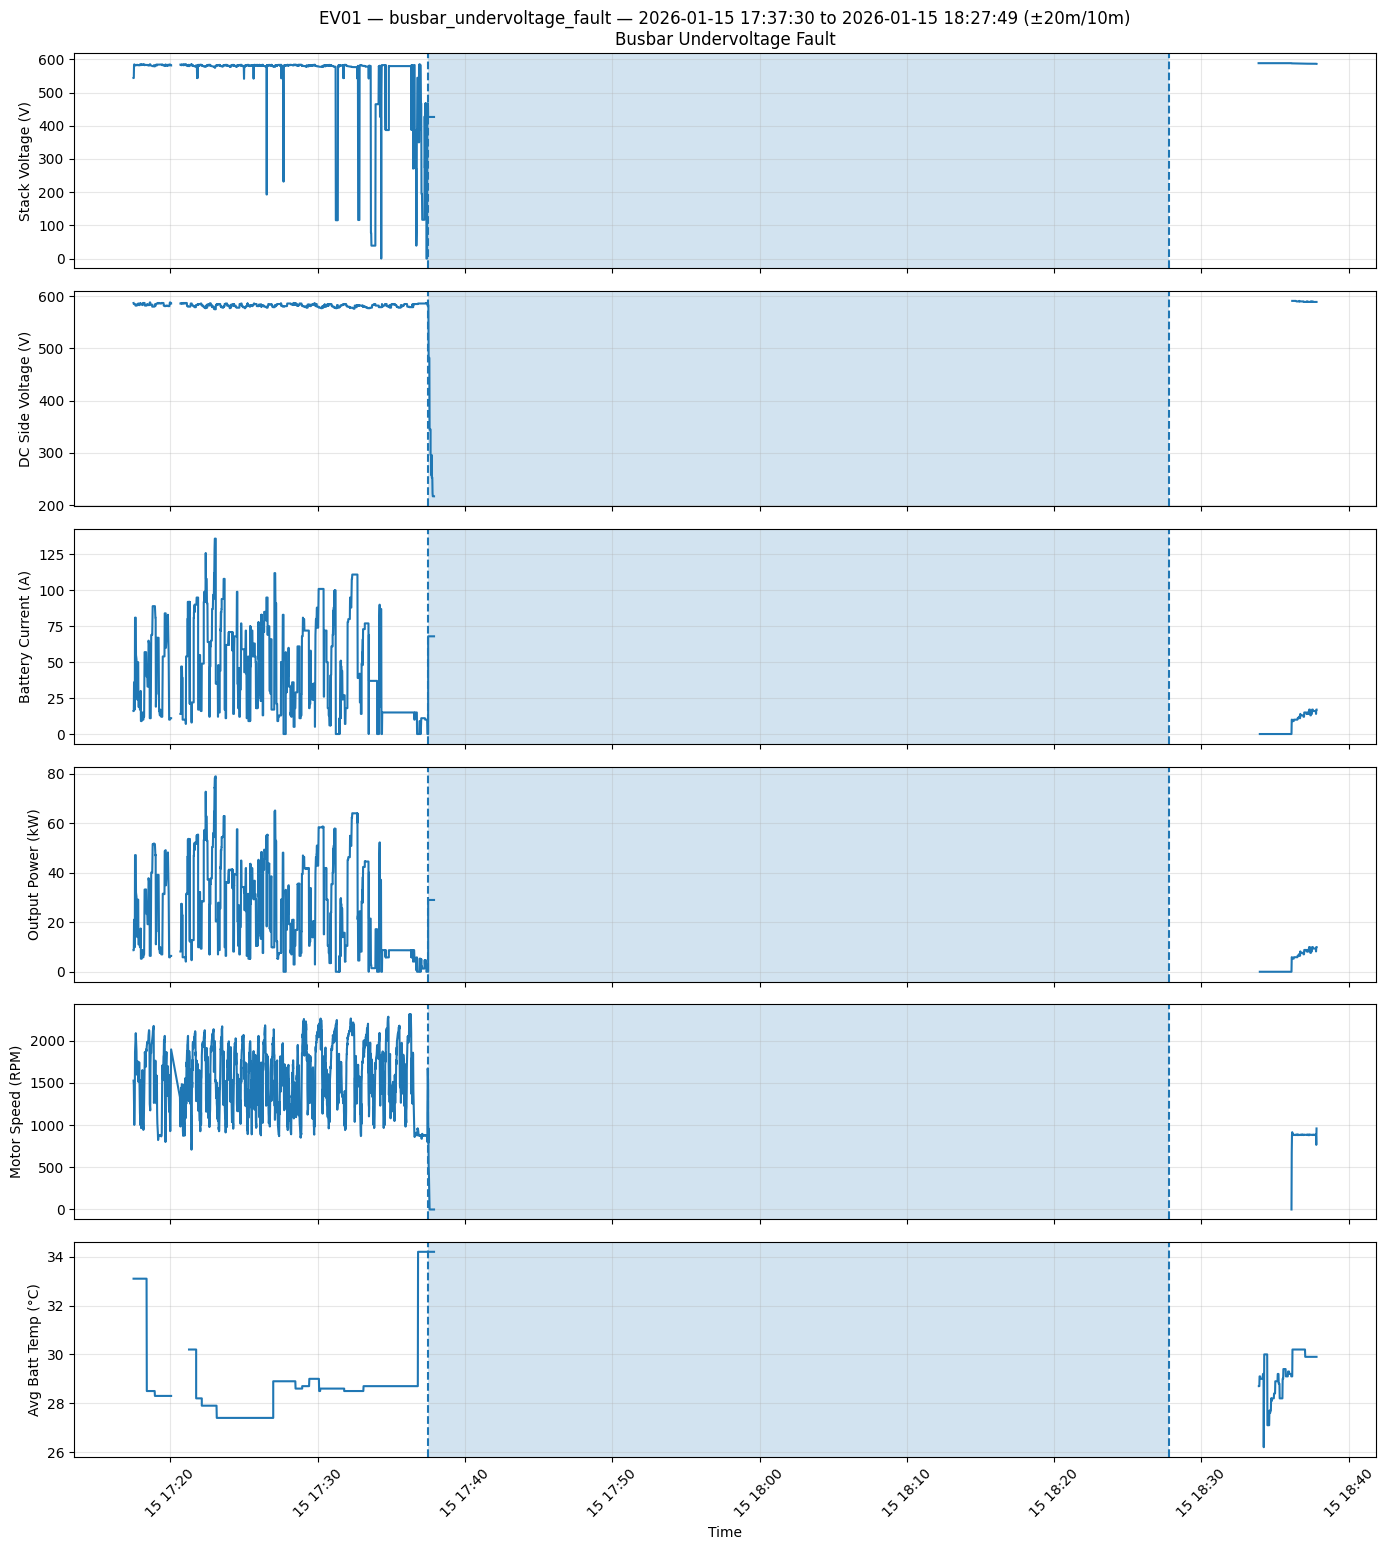


[8/8] busbar_undervoltage_fault | 2026-01-15 18:38:41 -> 2026-01-15 18:38:58


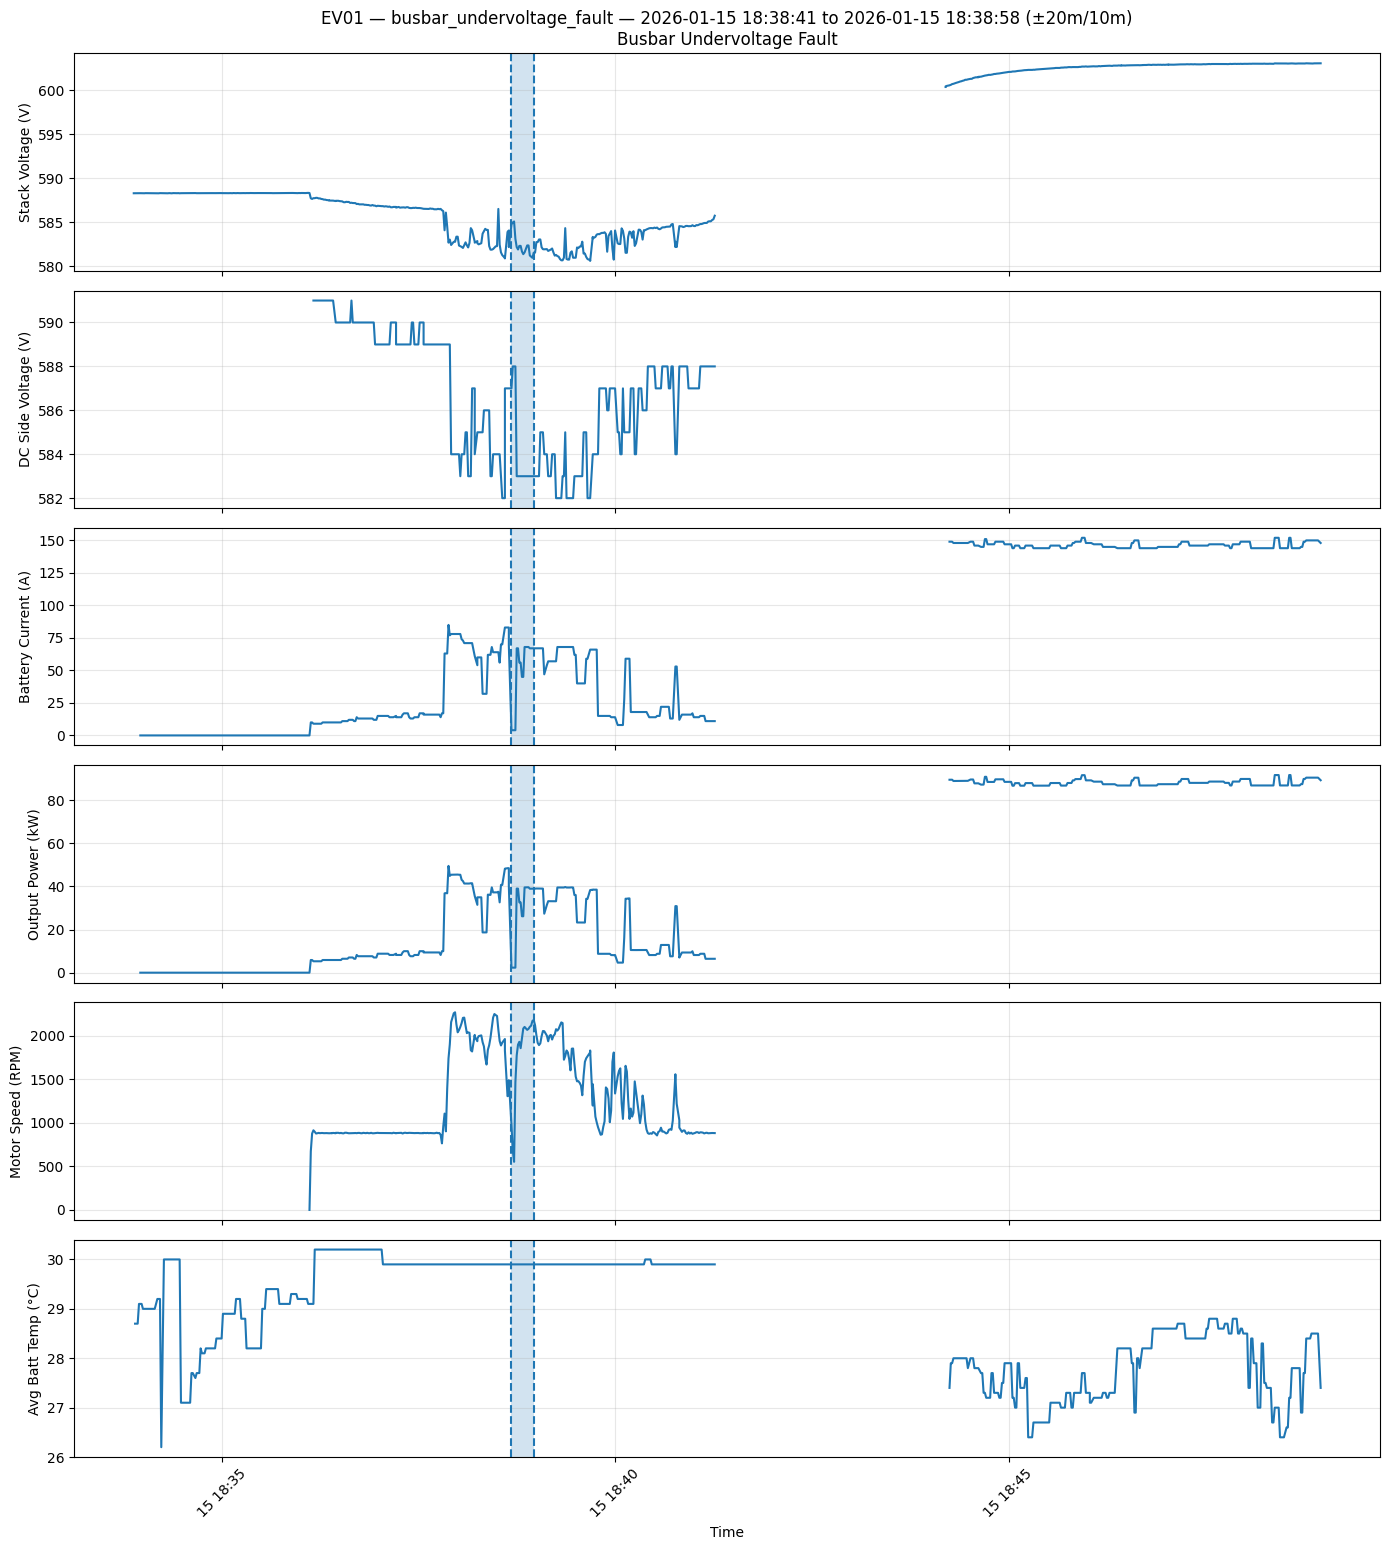

In [5]:
# -------------------------
# Per-fault zoomed plot (pre/post window)
# -------------------------

def plot_fault_window(frow):
    start = frow.activated_at - pd.Timedelta(minutes=PRE_MIN)
    end   = frow.fixed_at + pd.Timedelta(minutes=POST_MIN)
    seg = tel[(tel["Timestamp"] >= start) & (tel["Timestamp"] <= end)].copy()
    if len(seg) == 0:
        print("No telemetry found for window:", frow.code, start, end)
        return

    sigs = [(c, lbl) for c, lbl in [
        ("stack_voltage_v", "Stack Voltage (V)"),
        ("dc_side_voltage_v", "DC Side Voltage (V)"),
        ("battery_current_a", "Battery Current (A)"),
        ("output_power_kw", "Output Power (kW)"),
        ("motor_speed_rpm", "Motor Speed (RPM)"),
        ("avg_battery_temp_c", "Avg Batt Temp (°C)"),
    ] if c in seg.columns]

    fig, axes = plt.subplots(len(sigs), 1, figsize=(14, 2.6*len(sigs)), sharex=True)
    if len(sigs) == 1:
        axes = [axes]

    for ax, (c, lbl) in zip(axes, sigs):
        ax.plot(seg["Timestamp"], seg[c])
        ax.set_ylabel(lbl)
        ax.grid(True, alpha=0.3)
        ax.axvspan(frow.activated_at, frow.fixed_at, alpha=0.2)
        ax.axvline(frow.activated_at, linestyle="--")
        ax.axvline(frow.fixed_at, linestyle="--")

    title = f"{VEHICLE_ID} — {frow.code} — {frow.activated_at} to {frow.fixed_at} (±{PRE_MIN}m/{POST_MIN}m)"
    if "description" in frow.index and pd.notna(frow.get("description")):
        title += f"\n{frow.get('description')}"
    axes[0].set_title(title)
    axes[-1].set_xlabel("Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for i, r in faults.iterrows():
    print(f"\n[{i+1}/{len(faults)}] {r['code']} | {r['activated_at']} -> {r['fixed_at']}")
    plot_fault_window(r)

In [6]:
# -------------------------
# Simple signature probe: pre-fault vs same-day baseline z-scores
# -------------------------
BASELINE = tel_day.copy()

probe_cols = [c for c in [
    "stack_voltage_v",
    "dc_side_voltage_v",
    "battery_current_a",
    "output_power_kw",
    "motor_speed_rpm",
    "avg_battery_temp_c",
] if c in tel.columns]

baseline_stats = {}
for c in probe_cols:
    baseline_stats[c] = {
        "mean": float(pd.to_numeric(BASELINE[c], errors="coerce").mean()),
        "std": float(pd.to_numeric(BASELINE[c], errors="coerce").std()),
    }

rows = []
for _, f in faults.iterrows():
    pre_start = f.activated_at - pd.Timedelta(minutes=PRE_MIN)
    pre_end = f.activated_at
    pre = tel[(tel["Timestamp"] >= pre_start) & (tel["Timestamp"] < pre_end)]
    if len(pre) < 10:
        continue

    r = {
        "code": f.code,
        "activated_at": f.activated_at,
        "fixed_at": f.fixed_at,
        "pre_rows": int(len(pre)),
    }

    for c in probe_cols:
        pre_mean = float(pd.to_numeric(pre[c], errors="coerce").mean())
        base_mean = baseline_stats[c]["mean"]
        base_std = baseline_stats[c]["std"]
        z = np.nan
        if base_std and np.isfinite(base_std) and base_std > 1e-9:
            z = (pre_mean - base_mean) / base_std
        r[f"{c}_pre_mean"] = pre_mean
        r[f"{c}_z"] = z

    rows.append(r)

summary = pd.DataFrame(rows)
pd.set_option('display.max_columns', 200)
summary.sort_values(["activated_at", "code"])

,code,activated_at,fixed_at,pre_rows,stack_voltage_v_pre_mean,stack_voltage_v_z,dc_side_voltage_v_pre_mean,dc_side_voltage_v_z,battery_current_a_pre_mean,battery_current_a_z,output_power_kw_pre_mean,output_power_kw_z,motor_speed_rpm_pre_mean,motor_speed_rpm_z,avg_battery_temp_c_pre_mean,avg_battery_temp_c_z
0,busbar_undervoltage_fault,2026-01-15 17:12:56,2026-01-15 17:13:57,832,584.209785,0.078886,586.186298,-0.065811,25.242788,-0.383897,14.726797,-0.378506,1241.758413,-0.165615,33.005889,1.803156
1,busbar_undervoltage_fault,2026-01-15 17:14:13,2026-01-15 17:14:57,833,584.194370,0.078599,586.146459,-0.068126,25.058824,-0.388319,14.619004,-0.382844,1238.660264,-0.172267,33.005882,1.803152
2,bus_overvoltage_fault,2026-01-15 17:19:38,2026-01-15 17:19:58,851,556.460892,-0.439374,586.324324,-0.057793,25.045828,-0.388632,14.293437,-0.395947,1196.792009,-0.262157,32.725617,1.633843
5,busbar_undervoltage_fault,2026-01-15 17:19:38,2026-01-15 17:19:58,851,556.460892,-0.439374,586.324324,-0.057793,25.045828,-0.388632,14.293437,-0.395947,1196.792009,-0.262157,32.725617,1.633843
4,hardware_overvoltage_fault,2026-01-15 17:19:38,2026-01-15 17:19:58,851,556.460892,-0.439374,586.324324,-0.057793,25.045828,-0.388632,14.293437,-0.395947,1196.792009,-0.262157,32.725617,1.633843
3,total_hardware_failure,2026-01-15 17:19:38,2026-01-15 17:19:58,851,556.460892,-0.439374,586.324324,-0.057793,25.045828,-0.388632,14.293437,-0.395947,1196.792009,-0.262157,32.725617,1.633843
6,busbar_undervoltage_fault,2026-01-15 17:37:30,2026-01-15 18:27:49,1948,550.694978,-0.547062,582.198767,-0.297463,45.571135,0.104783,25.810564,0.067547,1555.161704,0.507253,28.670282,-0.816002
7,busbar_undervoltage_fault,2026-01-15 18:38:41,2026-01-15 18:38:58,299,586.834098,0.127900,588.179310,0.049971,17.292308,-0.575021,10.098815,-0.564754,1211.945946,-0.229622,29.449242,-0.345428


## How to interpret the z-score table

- Columns ending with `_z` are **z-scores**: how unusual the pre-fault mean is compared to the day baseline.
- Large magnitude values (e.g., `|z| >= 2`) suggest that signal is behaving unusually before the fault.

Typical patterns:
- **Undervoltage faults**: voltage z-score negative, current/power z-score positive
- **Overvoltage faults**: voltage z-score positive, often power/current instability
